In [100]:
import os
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


In [75]:
# Get the directory with the notebooks, including its subdirectories
current_dir = os.getcwd()

# Get the directories with data and results
data_dir = os.path.join(current_dir, "data")
temporary_dir= os.path.join(current_dir, "temporary_data")
results_dir = os.path.join(current_dir, "results")

project_dir = os.path.dirname(current_dir)

inputs_dir = os.path.join(project_dir, "inputs")



In [76]:
# After we need to put together the PSYS and Size values for each program in each of the 3 different implementations

# Example usage
csv_with_ec = os.path.join(results_dir, 'averagePSYS_all_repeats.csv')
# Read the first CSV file
df = pd.read_csv(csv_with_ec, delimiter=';')
df


,Program,Utilities,PSYS
0,base64,BusyBox,430354
1,base64,GNU,349505
2,base64,ToyBox,907798
3,basename,BusyBox,293713
4,basename,GNU,294027
...,...,...,...
79,true,GNU,294784
80,true,ToyBox,290862
81,wc,BusyBox,87557207
82,wc,GNU,454693407


In [77]:
# Note: The two following tables are in fact the used data 
# for Table 1 in the paper

df_pivot = df.pivot(index='Program', columns='Utilities')
df_pivot

PSYS                     
Utilities   BusyBox       GNU     ToyBox
Program                                 
base64       430354    349505     907798
basename     293713    294027     292617
cat        37555418   2125736 1517433316
chmod       1951976   1539669    1523403
cksum     245804675  11393452  206246027
comm      120871544  55065280  338316877
cp        111249422 108848403  147443488
cut         4932394   2207312   11399989
date         312215    315368     315307
dirname      310088    321538     312243
du           490593    523238     518535
echo         305297    321447     310885
expand     14566015   7273004     502358
factor       316259    321972     316164
false        305318    320141     314748
head         307940    320019     314822
id           308193    327917     313204
link         306344    317284     312356
ln           305120    322475     335705
logname      310082    322387     310830
ls           898063   1048413    3487467
md5sum    143150640 118599779  264030510
mkdir        297653    306612     300335
mv           295278    306939     296899
sort      318299265  95543426  469334196
touch        294509    295196     295181
true         294854    294784     290862
wc         87557207 454693407  151481253

In [78]:
# These are the DIFF.% values in Table 1 in the paper

df_pivot['Difference_BusyBox'] = ((df_pivot['PSYS']['BusyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
df_pivot['Difference_ToyBox'] = ((df_pivot['PSYS']['ToyBox'] - df_pivot['PSYS']['GNU']) / df_pivot['PSYS']['GNU']) * 100
new_df = pd.DataFrame({
                       'BusyBox': df_pivot['Difference_BusyBox'].round(2),
                       'ToyBox': df_pivot['Difference_ToyBox'].round(2)})
new_df

,BusyBox,ToyBox
Program,,
base64,23,160
basename,-0,-0
cat,1667,71284
chmod,27,-1
cksum,2057,1710
comm,120,514
cp,2,35
cut,123,416
date,-1,-0


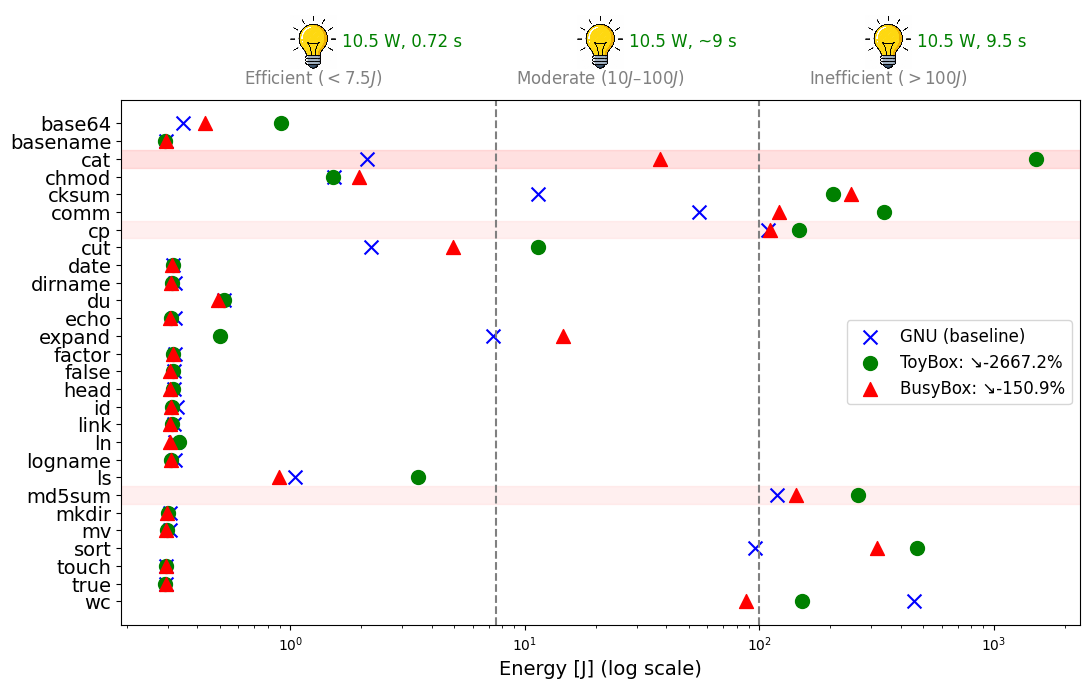

In [79]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load icon
bulb_img = plt.imread(os.path.join(current_dir, 'bulb.png'))

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label=f'ToyBox: ↘{mean_toy_energy:.1f}%')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label=f'BusyBox: ↘{mean_bb_energy:.1f}%')

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# Highlight 'cat' row with stronger red
cat_y = programs.tolist().index('cat')
ax.axhspan(cat_y - 0.5, cat_y + 0.5, color='#FF9999', alpha=0.3, zorder=0)

# Highlight 'cp' and 'md5sum' rows
positions = [programs.tolist().index('cp'), programs.tolist().index('md5sum')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color='#FFCCCC', alpha=0.3, zorder=0)

# place icons, keep labels at 1.02 and timing at 1.05
regions = [
    (0.2, 'Efficient ($< 7.5 J$)', '10.5 W, 0.72 s'),
    (0.5, 'Moderate ($10 J – 100 J$)', '10.5 W, ~9 s'),
    (0.8, 'Inefficient ($> 100 J$)', '10.5 W, 9.5 s')
]
for x, label, timing in regions:
    ab = AnnotationBbox(OffsetImage(bulb_img, zoom=0.05),
                       (x, 1.11), xycoords='axes fraction', frameon=False)
    ax.add_artist(ab)
    ax.text(x,       1.02, label,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=12, color='gray')
    ax.text(x + 0.03, 1.11, timing,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, color='green')

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'Energy [J] (log scale)', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

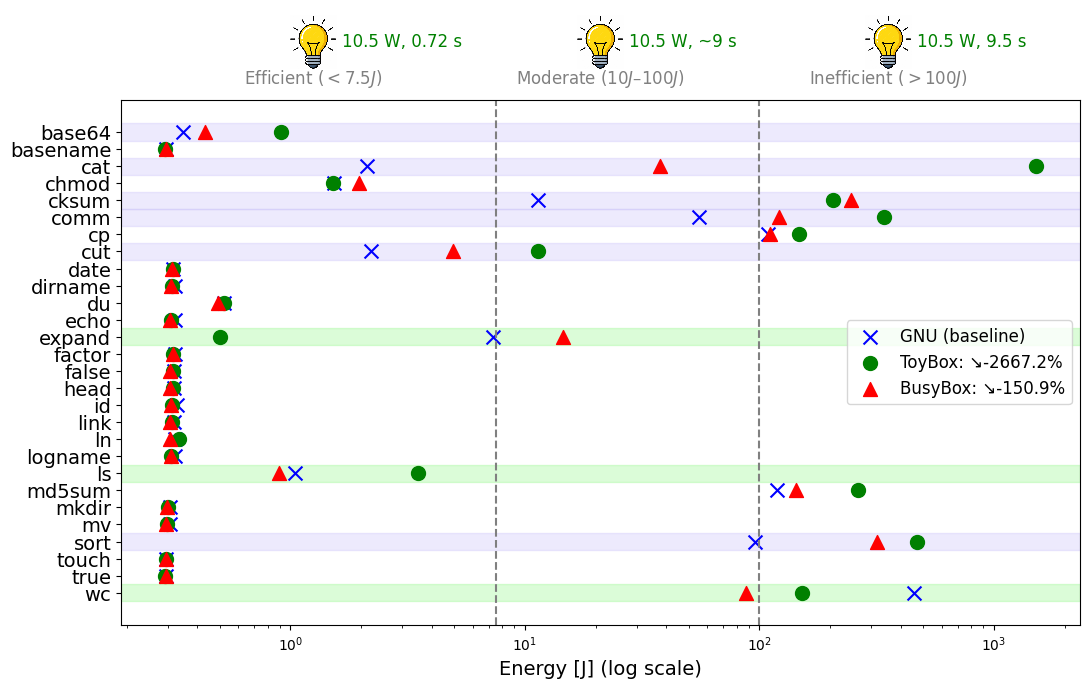

In [80]:
# Dot-plot of per-program energy (log scale) with mean-reduction legends
import os
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load icon
bulb_img = plt.imread(os.path.join(current_dir, 'bulb.png'))

# Extract energy for each implementation
bb = df_pivot['PSYS']['BusyBox']
gnu = df_pivot['PSYS']['GNU']
tb  = df_pivot['PSYS']['ToyBox']

# Program order as original (invert_yaxis() will flip display)
programs = df_pivot.index

# Compute mean energy reductions vs GNU
toy_energy_red = (gnu - tb) / gnu * 100
bb_energy_red  = (gnu - bb) / gnu * 100
mean_toy_energy = toy_energy_red.mean()
mean_bb_energy  = bb_energy_red.mean()

# convert microjoules to joules for plotting
gnu_j = gnu / 1e6
tb_j  = tb  / 1e6
bb_j  = bb  / 1e6

fig, ax = plt.subplots(figsize=(11, 7))

# Plot data points
ax.scatter(gnu_j, programs, marker='x', color='blue',  s=100, label='GNU (baseline)')
ax.scatter(tb_j,  programs, marker='o', color='green', s=100, label=f'ToyBox: ↘{mean_toy_energy:.1f}%')
ax.scatter(bb_j,  programs, marker='^', color='red',   s=100, label=f'BusyBox: ↘{mean_bb_energy:.1f}%')

ax.set_xscale('log')

# vertical region lines
ax.axvline(7.5, color='gray', linestyle='--')
ax.axvline(100, color='gray', linestyle='--')

# Highlight 'expand', 'ls', and 'wc' rows
positions = [programs.tolist().index('expand'), programs.tolist().index('ls'), programs.tolist().index('wc')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color="#89F77E", alpha=0.3, zorder=0)

# Highlight 'base64', 'cat', 'cksum', 'comm', 'cut', and 'sort' rows
positions = [programs.tolist().index('base64'), programs.tolist().index('cat'), programs.tolist().index('cksum'),
            programs.tolist().index('comm'), programs.tolist().index('cut'), programs.tolist().index('sort')]
for y in positions:
    ax.axhspan(y - 0.5, y + 0.5, color="#C4BAFA", alpha=0.3, zorder=0)

# place icons, keep labels at 1.02 and timing at 1.05
regions = [
    (0.2, 'Efficient ($< 7.5 J$)', '10.5 W, 0.72 s'),
    (0.5, 'Moderate ($10 J – 100 J$)', '10.5 W, ~9 s'),
    (0.8, 'Inefficient ($> 100 J$)', '10.5 W, 9.5 s')
]
for x, label, timing in regions:
    ab = AnnotationBbox(OffsetImage(bulb_img, zoom=0.05),
                       (x, 1.11), xycoords='axes fraction', frameon=False)
    ax.add_artist(ab)
    ax.text(x,       1.02, label,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=12, color='gray')
    ax.text(x + 0.03, 1.11, timing,
            transform=ax.transAxes, ha='left', va='center',
            fontsize=12, color='green')

# Flip the y-axis so programs and points reverse order
ax.invert_yaxis()

# use LaTeX mu for micro-symbol in xlabel
ax.set_xlabel(r'Energy [J] (log scale)', fontsize=14)
ax.legend(fontsize=12)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

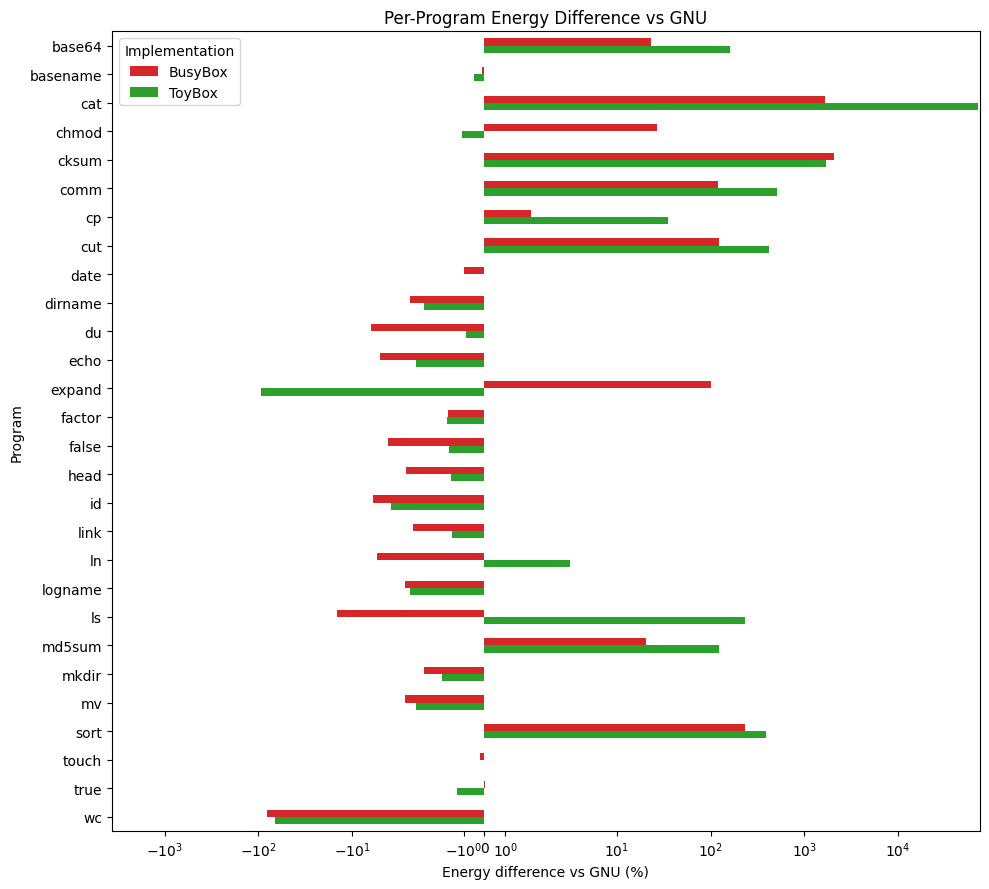

In [81]:
# Bar-plot of percent differences vs GNU (symlog scale)
import matplotlib.pyplot as plt

# new_df contains 'BusyBox' and 'ToyBox' diff percentages

fig, ax = plt.subplots(figsize=(10, 9))
new_df.plot(kind='barh', ax=ax, color=['#d62728', '#2ca02c'], legend=True)
# apply symmetric log scale with linear threshold around small values
ax.set_xscale('symlog', linthresh=5)
ax.set_xlabel('Energy difference vs GNU (%)')
ax.set_title('Per-Program Energy Difference vs GNU')
ax.legend(title='Implementation')
ax.invert_yaxis()  # keep program order top→bottom
plt.tight_layout()
plt.show()

In [82]:
# Summary statistics on per‐program energy consumption
# Count programs where ToyBox or BusyBox exceeds GNU
total = len(df_pivot)
toy_higher = (df_pivot['PSYS']['ToyBox'] > df_pivot['PSYS']['GNU']).sum()
bb_higher  = (df_pivot['PSYS']['BusyBox'] > df_pivot['PSYS']['GNU']).sum()
print(f"ToyBox > GNU: {toy_higher}/{total} programs ({toy_higher/total:.1%})")
print(f"BusyBox > GNU: {bb_higher}/{total} programs ({bb_higher/total:.1%})")

# Descriptive stats (microjoules) for each implementation
# Disable scientific notation and format count as integer
pd.options.display.float_format = '{:.0f}'.format
stats = df_pivot['PSYS'].describe()
print(stats)

ToyBox > GNU: 10/28 programs (35.7%)
BusyBox > GNU: 11/28 programs (39.3%)
Utilities   BusyBox       GNU     ToyBox
count            28        28         28
mean       39011444  30854240  111330620
std        80718862  89930548  301070527
min          293713    294027     290862
25%          305313    319335     311903
50%          314237    325196     325934
75%        20313366   3473735   45410864
max       318299265 454693407 1517433316


In [83]:
# Compute correlation between binary size (KiB) and energy consumption (J)

# Load binary sizes and convert to KiB
size_df = pd.read_csv(os.path.join(inputs_dir, 'programs30.csv'), delimiter=';')
size_df.set_index('Program', inplace=True)
sizes_kib = size_df[['GNU','BusyBox','ToyBox']] / 1024
sizes_kib = sizes_kib.rename(columns=lambda x: x + '_KiB')

# Extract energy (J) from df_pivot (which was in µJ)
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# Combine sizes and energy into one DataFrame
combined = sizes_kib.join(energy_j)

# Compute Spearman correlations
corr = combined.corr(method='spearman').round(2)
print('Correlation matrix between size [KiB] and energy [J]:')
print(corr)

# Specifically, how size of each implementation correlates with its own energy
for impl in ['GNU','BusyBox','ToyBox']:
    print(f"{impl} size vs energy: {corr.loc[f'{impl}_KiB', f'{impl}_J']:.2f}")

Correlation matrix between size [KiB] and energy [J]:
             GNU_KiB  BusyBox_KiB  ToyBox_KiB  BusyBox_J  GNU_J  ToyBox_J
GNU_KiB            1            1           1          0      0         0
BusyBox_KiB        1            1           1          0      0         0
ToyBox_KiB         1            1           1          0      0         0
BusyBox_J          0            0           0          1      1         1
GNU_J              0            0           0          1      1         1
ToyBox_J           0            0           0          1      1         1
GNU size vs energy: 0.25
BusyBox size vs energy: 0.30
ToyBox size vs energy: 0.35


In [84]:
# Correlation between # configuration options and energy consumption
opts_df = pd.read_csv(os.path.join(inputs_dir, 'programs_nr_options30.csv'), delimiter=';')
opts_df.set_index('Program', inplace=True)
opts = opts_df[['GNU', 'BusyBox', 'ToyBox']].rename(columns=lambda x: x + '_opts')

# Energy in joules
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# Combine options and energy
combined_opts = opts.join(energy_j)

# Compute Spearman correlations
corr_opts = combined_opts.corr(method='spearman').round(2)
print('Correlation matrix between #options and energy [J]:')
print(corr_opts)

# Per-implementation correlation
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    print(f"{impl} opts vs energy: {corr_opts.loc[f'{impl}_opts', f'{impl}_J']:.2f}")

Correlation matrix between #options and energy [J]:
              GNU_opts  BusyBox_opts  ToyBox_opts  BusyBox_J  GNU_J  ToyBox_J
GNU_opts             1             1            1          0      0         1
BusyBox_opts         1             1            1          0      0         0
ToyBox_opts          1             1            1          0      0         0
BusyBox_J            0             0            0          1      1         1
GNU_J                0             0            0          1      1         1
ToyBox_J             1             0            0          1      1         1
GNU opts vs energy: 0.46
BusyBox opts vs energy: 0.27
ToyBox opts vs energy: 0.39


In [85]:
# Correlation between execution time (s) and energy consumption (J)
# load and pivot runtime data
dur_file = os.path.join(results_dir, 'averageDURATION_all_repeats.csv')
df_dur   = pd.read_csv(dur_file, delimiter=';')
time_df  = df_dur.pivot(index='Program', columns='Utilities', values='DURATION')
time_s   = time_df.rename(columns=lambda x: x + '_s')

# energy in joules
energy_j = df_pivot['PSYS'] / 1e6
energy_j = energy_j.rename(columns=lambda x: x + '_J')

# combine and compute Spearman correlations
combined_time = time_s.join(energy_j)
corr_time    = combined_time.corr(method='spearman').round(2)
print('Correlation matrix between runtime [s] and energy [J]:')
print(corr_time)

# per-implementation correlation
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    print(f"{impl} time vs energy: {corr_time.loc[f'{impl}_s', f'{impl}_J']:.2f}")

Correlation matrix between runtime [s] and energy [J]:
Utilities  BusyBox_s  GNU_s  ToyBox_s  BusyBox_J  GNU_J  ToyBox_J
Utilities                                                        
BusyBox_s          1      1         1          1      1         1
GNU_s              1      1         1          1      1         1
ToyBox_s           1      1         1          1      1         1
BusyBox_J          1      1         1          1      1         1
GNU_J              1      1         1          1      1         1
ToyBox_J           1      1         1          1      1         1
GNU time vs energy: 0.89
BusyBox time vs energy: 0.96
ToyBox time vs energy: 0.97


**Note:** The `DURATION` field corresponds to the measured execution time (in seconds) for each program run.

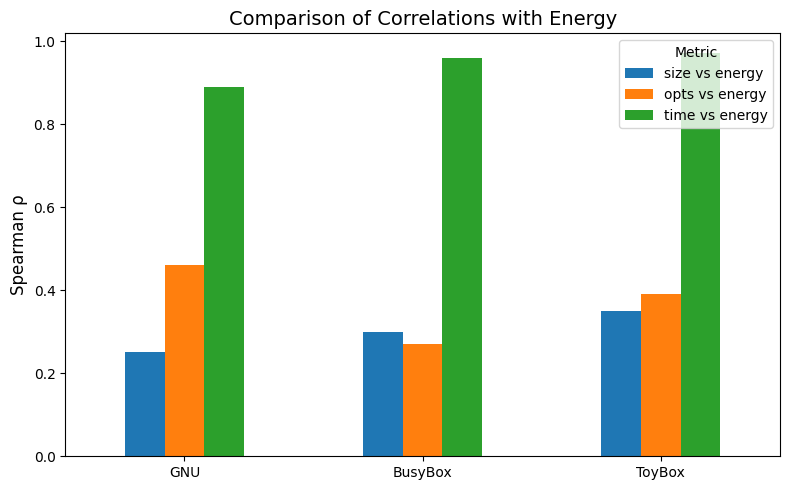

In [87]:
# Compare correlations in one plot
corr_summary = pd.DataFrame({
    'size vs energy': [
        corr.loc['GNU_KiB','GNU_J'],
        corr.loc['BusyBox_KiB','BusyBox_J'],
        corr.loc['ToyBox_KiB','ToyBox_J']
    ],
    'opts vs energy': [
        corr_opts.loc['GNU_opts','GNU_J'],
        corr_opts.loc['BusyBox_opts','BusyBox_J'],
        corr_opts.loc['ToyBox_opts','ToyBox_J']
    ],
    'time vs energy': [
        corr_time.loc['GNU_s','GNU_J'],
        corr_time.loc['BusyBox_s','BusyBox_J'],
        corr_time.loc['ToyBox_s','ToyBox_J']
    ]
}, index=['GNU','BusyBox','ToyBox'])

ax = corr_summary.plot.bar(figsize=(8,5))
ax.set_ylabel('Spearman ρ', fontsize=12)
ax.set_title('Comparison of Correlations with Energy', fontsize=14)
ax.legend(loc='upper right', title='Metric', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [89]:
# Summary: execution time vs energy correlations
for impl in ['GNU', 'BusyBox', 'ToyBox']:
    rho = corr_time.loc[f'{impl}_s', f'{impl}_J']
    print(f"{impl} time vs energy: {rho:.2f}")

GNU time vs energy: 0.89
BusyBox time vs energy: 0.96
ToyBox time vs energy: 0.97


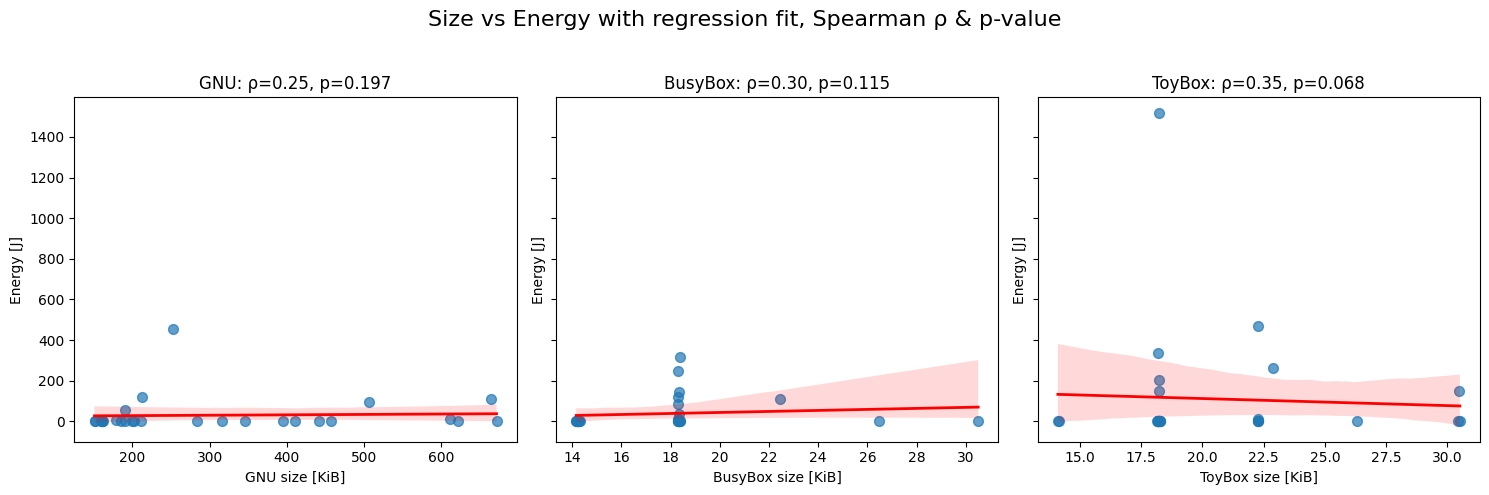

In [94]:
# Scatter + regression: size vs. energy per implementation
import seaborn as sns

impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    # join and drop NaNs to match lengths
    tmp = pd.concat([sizes_kib[f'{impl}_KiB'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_KiB']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50, 'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} size [KiB]')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)

plt.suptitle('Size vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

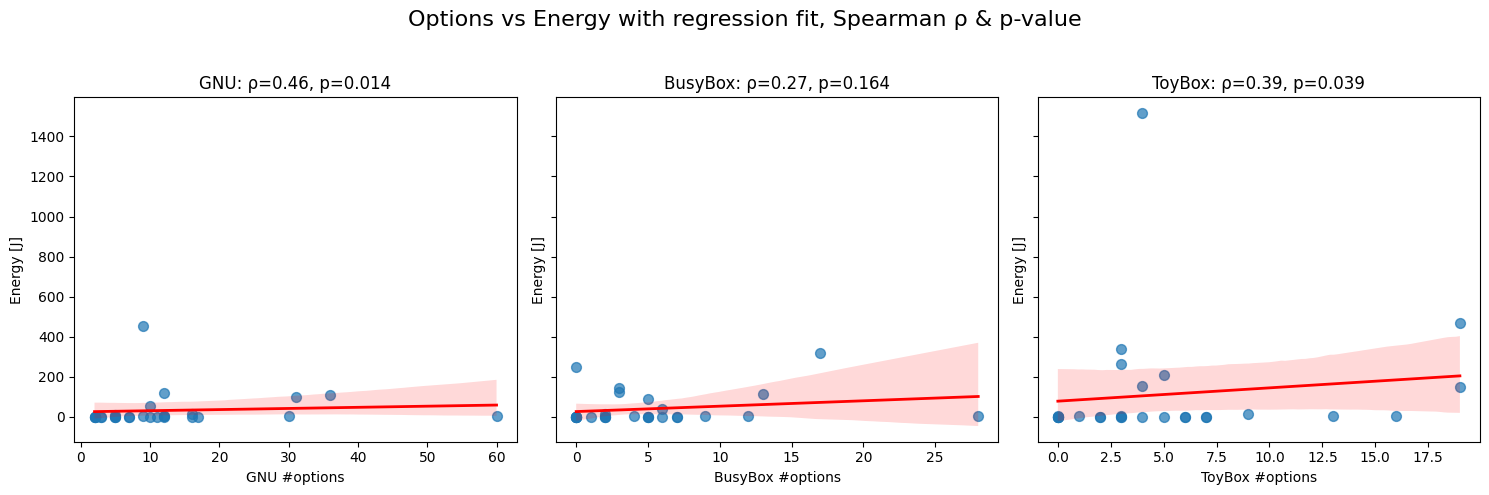

In [95]:
# Scatter + regression: options vs. energy per implementation
import seaborn as sns
impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    tmp = pd.concat([opts[f'{impl}_opts'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_opts']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50,'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} #options')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)
plt.suptitle('Options vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

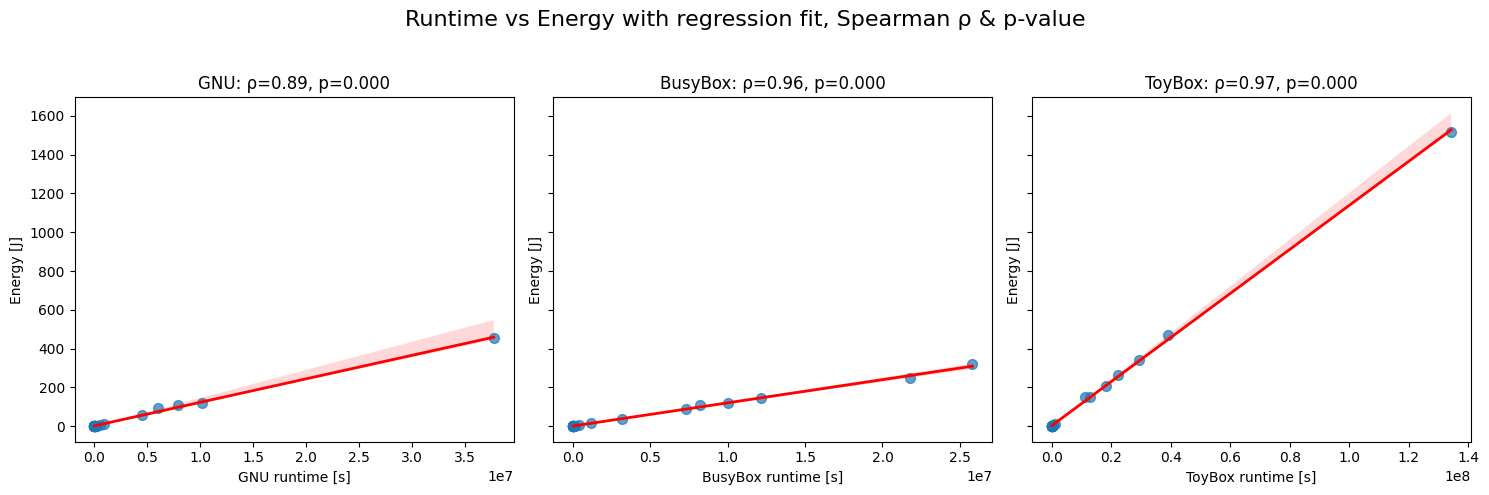

In [96]:
# Scatter + regression: time vs. energy per implementation
import seaborn as sns
impls = ['GNU','BusyBox','ToyBox']
fig, axes = plt.subplots(1, len(impls), figsize=(15,5), sharey=True)
for ax, impl in zip(axes, impls):
    tmp = pd.concat([time_s[f'{impl}_s'], energy_j[f'{impl}_J']], axis=1).dropna()
    x = tmp[f'{impl}_s']
    y = tmp[f'{impl}_J']
    rho, pval = spearmanr(x, y)
    sns.regplot(x=x, y=y, ax=ax, fit_reg=True,
                scatter_kws={'s':50,'alpha':0.7},
                line_kws={'color':'red','lw':2})
    ax.set_xlabel(f'{impl} runtime [s]')
    ax.set_ylabel('Energy [J]')
    ax.set_title(f'{impl}: ρ={rho:.2f}, p={pval:.3f}', fontsize=12)
plt.suptitle('Runtime vs Energy with regression fit, Spearman ρ & p-value', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

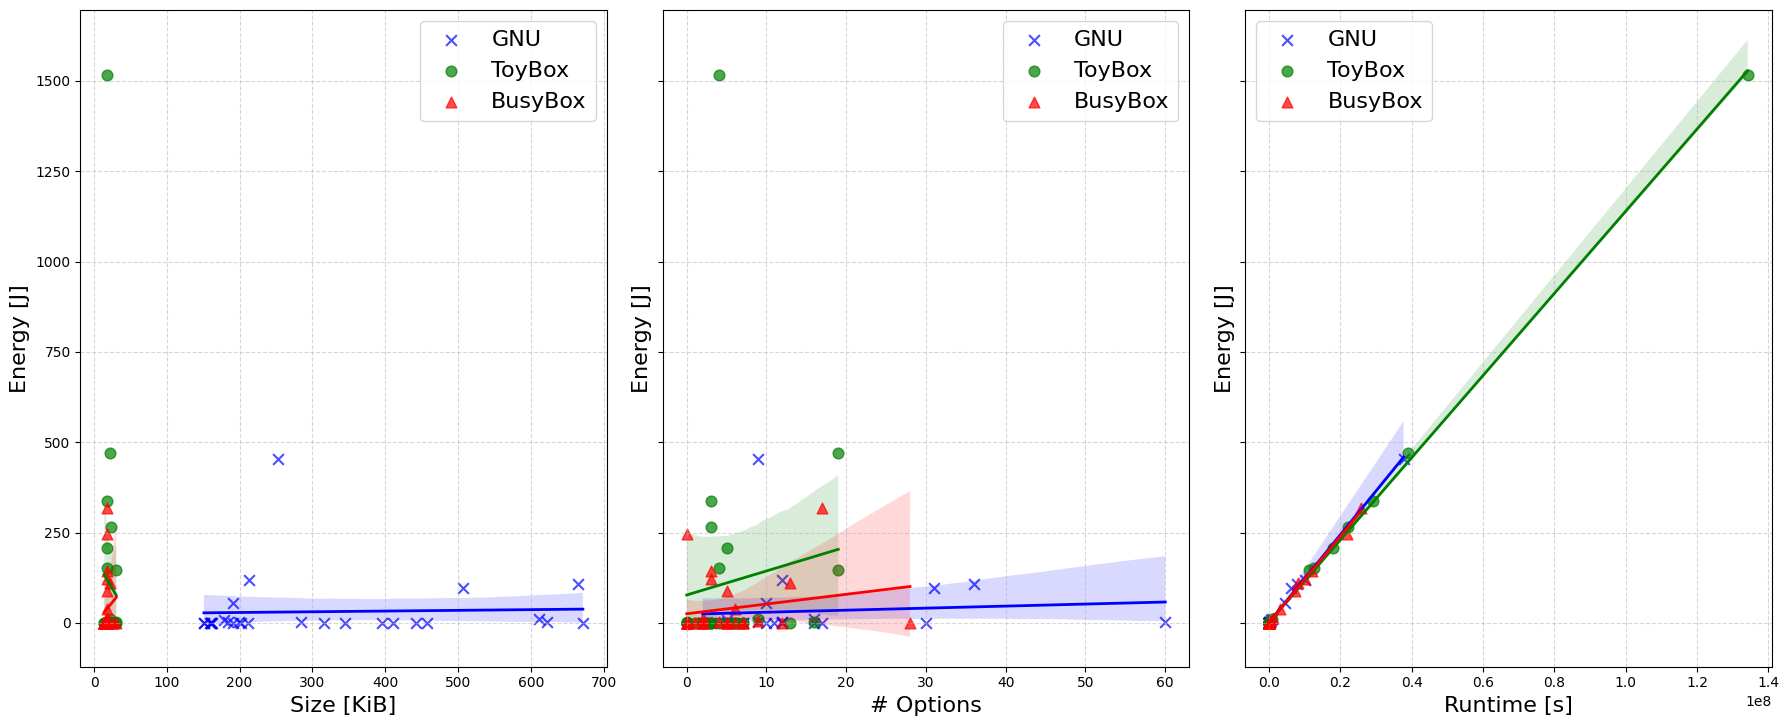

In [113]:
# Combined scatter: size, options, and time vs. energy
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
params = [
    ('Size [KiB]', sizes_kib, '_KiB'),
    ('# Options', opts, '_opts'),
    ('Runtime [s]', time_s, '_s')
]
colors = {'GNU':'blue', 'ToyBox':'green', 'BusyBox':'red'}
markers = {'GNU':'x', 'ToyBox':'o', 'BusyBox':'^'}
for ax, (xlabel, df_param, suffix) in zip(axes, params):
    for impl in ['GNU','ToyBox','BusyBox']:
        tmp = pd.concat([df_param[f'{impl}{suffix}'], energy_j[f'{impl}_J']], axis=1).dropna()
        x = tmp[f'{impl}{suffix}']
        y = tmp[f'{impl}_J']
        ax.scatter(x, y, label=impl, color=colors[impl], marker=markers[impl], s=60, alpha=0.7)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=colors[impl], line_kws={'lw':2})
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel('Energy [J]', fontsize=16)
    ax.legend(fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
# plt.suptitle('Metrics vs Energy (Scatter + Linear Fit)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

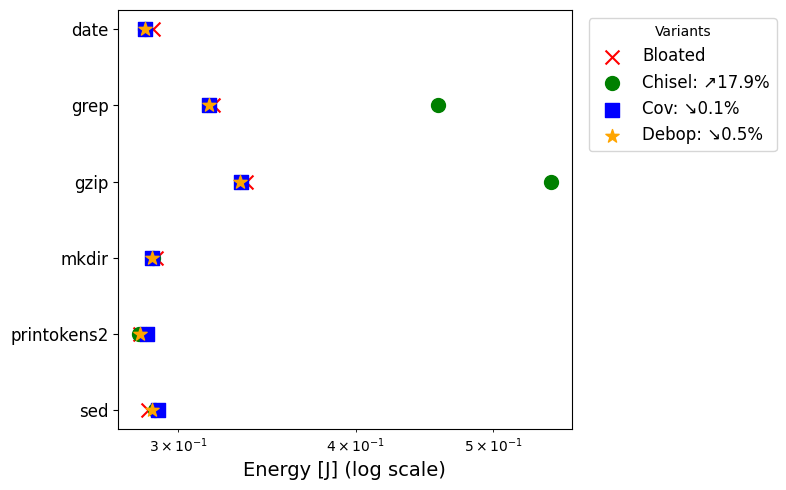

In [130]:
# Dot-plot per-program energy for bloated vs debloated variants
import pandas as pd, matplotlib.pyplot as plt

# load and average PSYS energy (µJ) per Program & Utilities
df = pd.read_csv(
    '/home/ternava/Documents/GitHub/bloat-energy-consumption/notebooks/debloating_results/cat_all_repeats.csv',
    delimiter=';'
)
psys_avg = df.groupby(['Program','Utilities'])['PSYS'].mean().unstack()

# convert to joules
psys_j = psys_avg / 1e6

# prepare data
prog = psys_j.index
baseline = psys_j['bloated']
variants = ['chisel','cov','debop']
markers = {'chisel':'o','cov':'s','debop':'*'}
colors = {'chisel':'green','cov':'blue','debop':'orange'}

# compute mean % reduction vs baseline
pct = (baseline.values[:,None] - psys_j[variants].values) / baseline.values[:,None] * 100
mean_pct = dict(zip(variants, pct.mean(axis=0)))

# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(baseline, prog, marker='x', color='red',   s=100, label='Bloated')
for v in variants:
    arr   = psys_j[v]
    mpct  = mean_pct[v]
    arrow = '↘' if mpct>0 else '↗'
    lbl   = f"{v.capitalize()}: {arrow}{abs(mpct):.1f}%"
    ax.scatter(arr, prog, marker=markers[v], color=colors[v], s=100, label=lbl)

ax.set_xscale('log')
ax.set_xlabel('Energy [J] (log scale)', fontsize=14)
#ax.set_ylabel('Program')
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, title='Variants', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

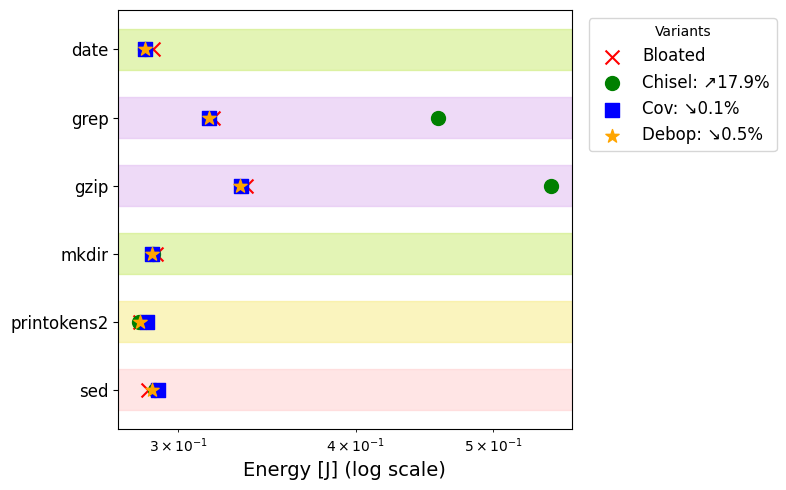

In [134]:
# Dot-plot per-program energy for bloated vs debloated variants (with highlights)
import pandas as pd, matplotlib.pyplot as plt

# load & average PSYS energy (µJ) per Program & Utilities
df = pd.read_csv(
    '/home/ternava/Documents/GitHub/bloat-energy-consumption/notebooks/debloating_results/cat_all_repeats.csv',
    delimiter=';'
)
psys_avg = df.groupby(['Program','Utilities'])['PSYS'].mean().unstack()
psys_j   = psys_avg / 1e6

# prepare data
prog      = psys_j.index
baseline  = psys_j['bloated']
variants  = ['chisel','cov','debop']
markers   = {'chisel':'o','cov':'s','debop':'*'}
colors    = {'chisel':'green','cov':'blue','debop':'orange'}
pct       = (baseline.values[:,None] - psys_j[variants].values) / baseline.values[:,None] * 100
mean_pct  = dict(zip(variants, pct.mean(axis=0)))

# plot points
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(baseline, prog, marker='x', color='red', s=100, label='Bloated')
for v in variants:
    arr   = psys_j[v]
    mpct  = mean_pct[v]
    arrow = '↘' if mpct>0 else '↗'
    lbl   = f"{v.capitalize()}: {arrow}{abs(mpct):.1f}%"
    ax.scatter(arr, prog, marker=markers[v], color=colors[v], s=100, label=lbl)
ax.set_xscale('log')

# highlight date, mkdir, printokens2 in light red (narrower)
for name in ['sed']:
    y = prog.tolist().index(name)
    ax.axhspan(y-0.3, y+0.3, color='#FFCCCC', alpha=0.5, zorder=0)
# highlight sed in light yellow (narrower)
for name in ['date','mkdir']:
    y = prog.tolist().index(name)
    ax.axhspan(y-0.3, y+0.3, color="#C9EB6C", alpha=0.5, zorder=0)
# highlight printokens2 in light yellow (narrower)
for name in ['printokens2']:
    y = prog.tolist().index(name)
    ax.axhspan(y-0.3, y+0.3, color="#F7EB7F", alpha=0.5, zorder=0)
# highlight grep and gzip in light green (narrower)
for name in ['grep','gzip']:
    y = prog.tolist().index(name)
    ax.axhspan(y-0.3, y+0.3, color="#DFB7F1", alpha=0.5, zorder=0)

ax.set_xlabel('Energy [J] (log scale)', fontsize=14)
#ax.set_ylabel('Program')
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12, title='Variants', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()